# 1. Analyse et compréhension des données

Cette section présente la structure du dataset, la variable cible, les valeurs manquantes, les valeurs aberrantes et la distribution des données.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = "Data/ESC 12 Pavement Dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dimensions du dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print("Variable cible : Needs Maintenance")
display(df.head())
display(df.dtypes.to_frame(name="Type"))
display(df["Needs Maintenance"].value_counts().rename("Effectif").to_frame())

Dimensions du dataset : 1,050,000 lignes x 10 colonnes
Variable cible : Needs Maintenance


,Segment ID,PCI,Road Type,AADT,Asphalt Type,Last Maintenance,Average Rainfall,Rutting,IRI,Needs Maintenance
0,SID 155440,70.00,Secondary,4634,Concrete,2022,42.07,15.11,0.68,0
1,SID 244365,37.87,Tertiary,3474,Asphalt,2017,79.60,19.67,0.99,1
2,SID 137867,88.32,Tertiary,1734,Concrete,2019,62.69,14.73,0.50,0
3,SID 540519,52.30,Tertiary,3119,Asphalt,2008,79.32,17.01,1.04,1
4,SID 745776,49.10,Tertiary,3505,Asphalt,2019,71.81,21.08,1.18,1


,Type
Segment ID,object
PCI,float64
Road Type,object
AADT,int64
Asphalt Type,object
Last Maintenance,int64
Average Rainfall,float64
Rutting,float64
IRI,float64
Needs Maintenance,int64


,Effectif
Needs Maintenance,
0,525131
1,524869


,Valeurs manquantes
Segment ID,0
PCI,0
Road Type,0
AADT,0
Asphalt Type,0
Last Maintenance,0
Average Rainfall,0
Rutting,0
IRI,0
Needs Maintenance,0


,Variable,Outliers,Borne basse,Borne haute
0,PCI,0,-45.155,155.205
1,AADT,58069,-18941.500,37670.500
2,Last Maintenance,106410,2011.000,2027.000
3,Average Rainfall,8,4.855,125.135
4,Rutting,0,6.200,27.000
5,IRI,5477,0.210,1.490


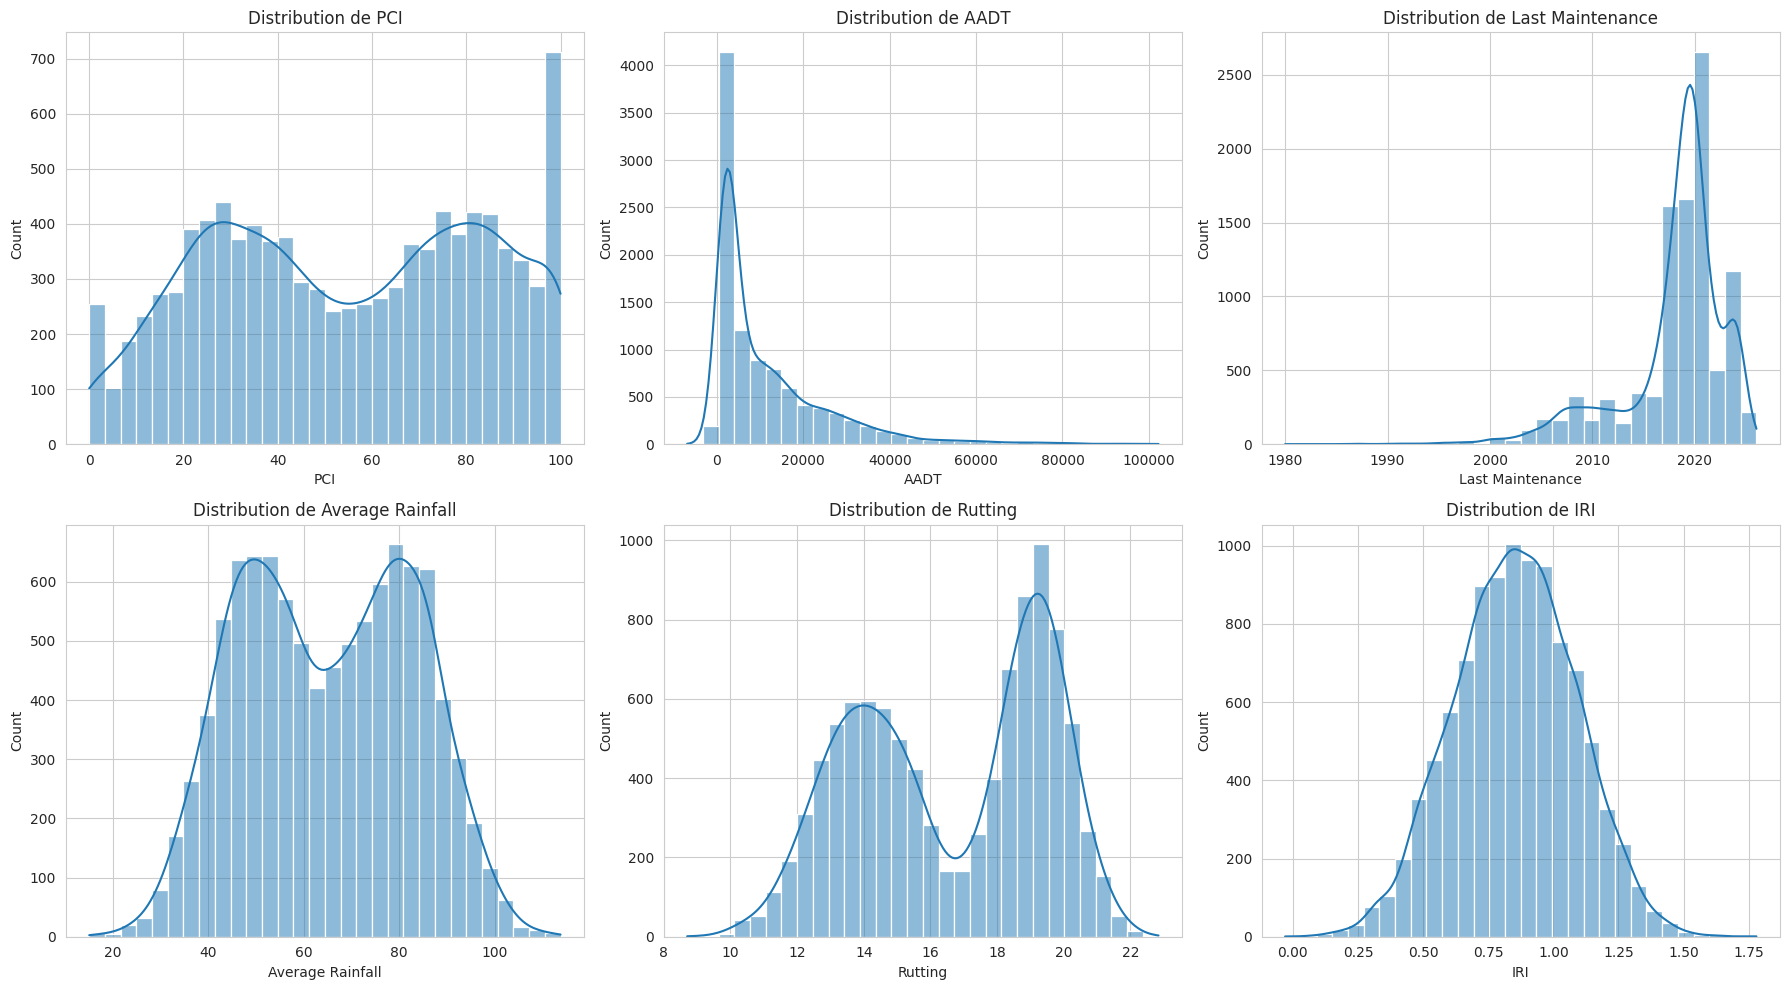

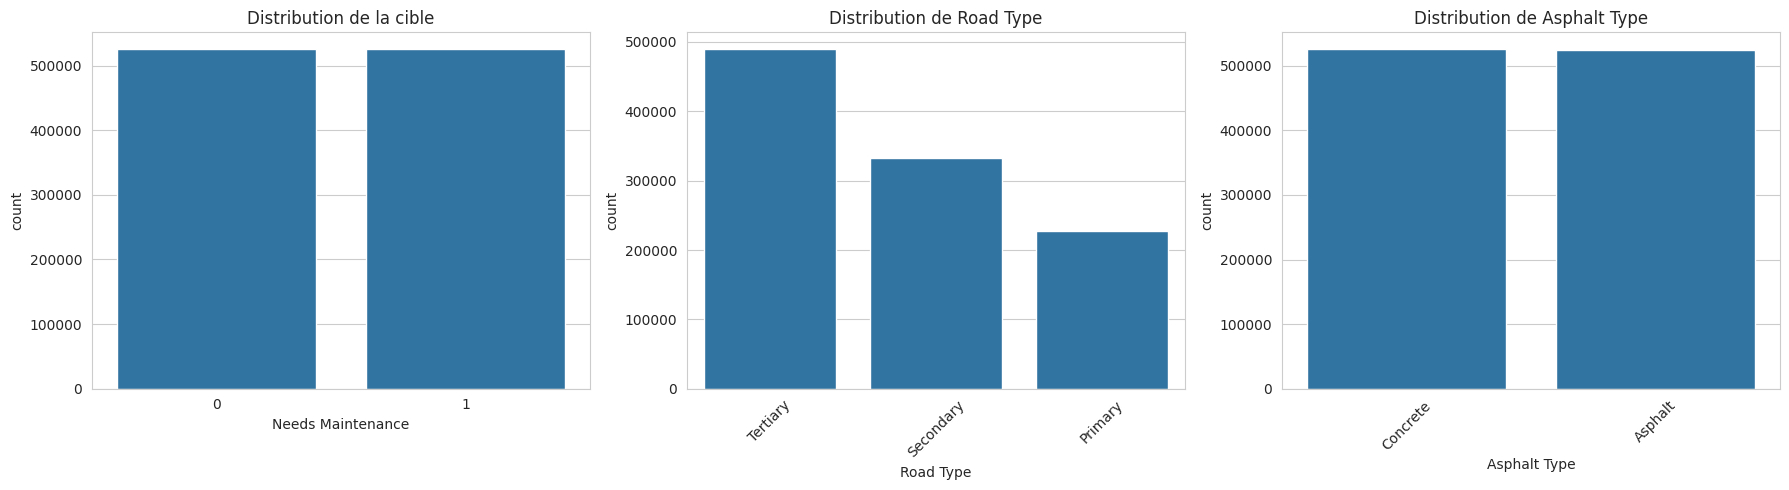

In [2]:
# Valeurs manquantes
missing_values = df.isna().sum().to_frame(name="Valeurs manquantes")
display(missing_values)

# Valeurs aberrantes avec la règle IQR sur les variables numériques
numeric_features = ["PCI", "AADT", "Last Maintenance", "Average Rainfall", "Rutting", "IRI"]
outlier_summary = []
for column in numeric_features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    count_outliers = int(((df[column] < lower_bound) | (df[column] > upper_bound)).sum())
    outlier_summary.append({
        "Variable": column,
        "Outliers": count_outliers,
        "Borne basse": lower_bound,
        "Borne haute": upper_bound
    })
display(pd.DataFrame(outlier_summary))

# Distribution des données
plot_df = df.sample(n=min(len(df), 10000), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, column in zip(axes, numeric_features):
    sns.histplot(plot_df[column], kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribution de {column}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x="Needs Maintenance", ax=axes[0])
axes[0].set_title("Distribution de la cible")

sns.countplot(data=df, x="Road Type", order=df["Road Type"].value_counts().index, ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Distribution de Road Type")

sns.countplot(data=df, x="Asphalt Type", order=df["Asphalt Type"].value_counts().index, ax=axes[2])
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_title("Distribution de Asphalt Type")

plt.tight_layout()
plt.show()

# 2. Prétraitement des données

Cette section traite les valeurs manquantes, encode les variables catégorielles, normalise les variables numériques pour KNN, puis sépare les données en train et test.

In [5]:
feature_columns = ["PCI", "Road Type", "AADT", "Asphalt Type", "Last Maintenance", "Average Rainfall", "Rutting", "IRI"]
target_column = "Needs Maintenance"

X = df[feature_columns]
y = df[target_column]

numeric_features = ["PCI", "AADT", "Last Maintenance", "Average Rainfall", "Rutting", "IRI"]
categorical_features = ["Road Type", "Asphalt Type"]

def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder())
        ]), categorical_features)
    ]
)

knn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder())
        ]), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Taille du train : {X_train.shape}")
print(f"Taille du test : {X_test.shape}")

Taille du train : (840000, 8)
Taille du test : (210000, 8)


# 3. Modélisation

Cette section entraîne les deux modèles demandés : l'arbre de décision et le KNN. Une validation croisée est appliquée sur l'ensemble d'entraînement pour comparer leur stabilité.

In [6]:
models = {
    "Arbre de décision": Pipeline(steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocessor", knn_preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ])
}

results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_train, y_train)
    results[name] = {
        "model": model,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }
    print(f"{name} - Validation croisée : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Arbre de décision - Validation croisée : 0.9995 ± 0.0000
KNN - Validation croisée : 1.0000 ± 0.0000


# 4. Évaluation des modèles

Pour chaque modèle, on calcule l'accuracy et la matrice de confusion sur l'ensemble de test.

Arbre de décision - Accuracy : 0.9996
[[104989     37]
 [    40 104934]]

KNN - Accuracy : 0.9999
[[105017      9]
 [     4 104970]]



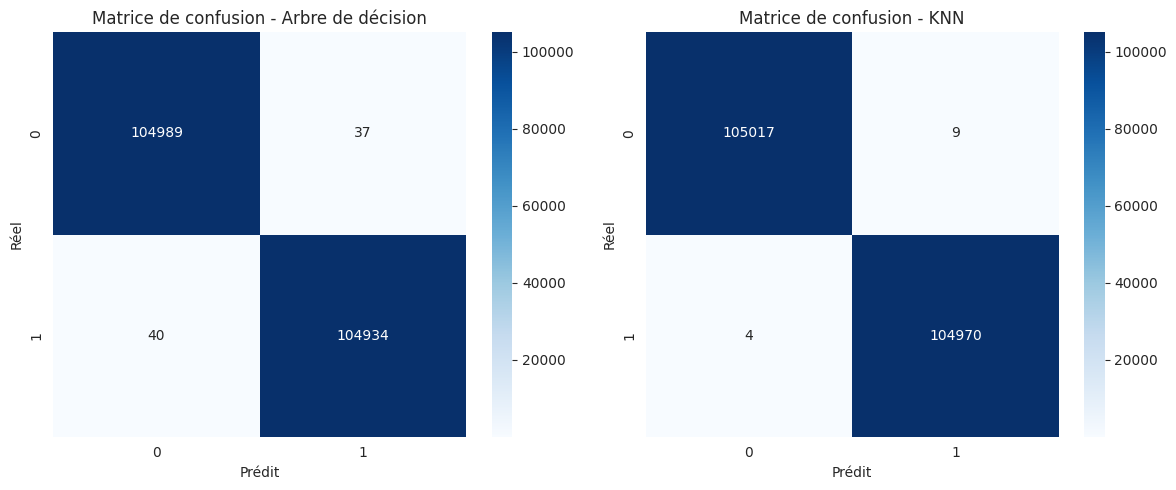

In [7]:
evaluation = {}

for name, info in results.items():
    model = info["model"]
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    evaluation[name] = {
        "accuracy": acc,
        "confusion_matrix": cm
    }
    print(f"{name} - Accuracy : {acc:.4f}")
    print(cm)
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, metrics) in zip(axes, evaluation.items()):
    sns.heatmap(metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Matrice de confusion - {name}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.show()

# 5. Comparaison et interprétation

Cette section compare les performances des deux modèles, identifie le meilleur et le plus robuste, puis discute l'impact du prétraitement.

In [8]:
comparison = pd.DataFrame({
    "Modèle": list(evaluation.keys()),
    "Accuracy": [evaluation[name]["accuracy"] for name in evaluation],
    "CV Mean": [results[name]["cv_mean"] for name in evaluation],
    "CV Std": [results[name]["cv_std"] for name in evaluation]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

display(comparison)

best_model_name = comparison.loc[0, "Modèle"]
most_robust_model_name = comparison.sort_values("CV Std", ascending=True).iloc[0]["Modèle"]

print(f"Meilleur modèle selon l'accuracy : {best_model_name}")
print(f"Modèle le plus robuste selon la validation croisée : {most_robust_model_name}")

,Modèle,Accuracy,CV Mean,CV Std
0,KNN,0.999938,0.999954,0.000019
1,Arbre de décision,0.999633,0.999521,0.000050


Meilleur modèle selon l'accuracy : KNN
Modèle le plus robuste selon la validation croisée : KNN


- L'encodage des variables catégorielles est indispensable pour les deux modèles.
- La standardisation améliore surtout KNN, car ce modèle dépend des distances entre observations.
- L'arbre de décision est moins sensible à l'échelle des variables, mais il profite aussi du nettoyage et de l'encodage.
- Le meilleur modèle est celui qui obtient la meilleure accuracy sur le test, tandis que le plus robuste est celui qui présente la plus faible variabilité en validation croisée.